<a href="https://colab.research.google.com/github/subashini123-ctrl/Deep-Learning-for-Vision/blob/main/Ex5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/3
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 154ms/step - accuracy: 0.4595 - loss: 0.7053 - val_accuracy: 0.4838 - val_loss: 0.6984
Epoch 2/3
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 132ms/step - accuracy: 0.4934 - loss: 0.6945 - val_accuracy: 0.5526 - val_loss: 0.6895
Epoch 3/3
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 183ms/step - accuracy: 0.5995 - loss: 0.6856 - val_accuracy: 0.6493 - val_loss: 0.6803
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.6502 - loss: 0.6802
Test Accuracy: 65.02%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step


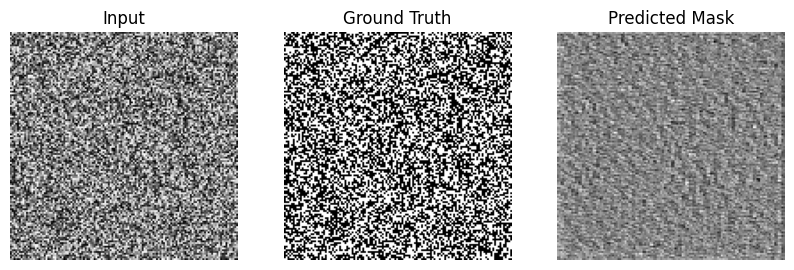

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

x_train = np.random.rand(100, 128, 128, 1)
y_train = (x_train > 0.5).astype(np.float32)

x_test = np.random.rand(10, 128, 128, 1)
y_test = (x_test > 0.5).astype(np.float32)

inputs = layers.Input((128, 128, 1))

c1 = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(inputs)
p1 = layers.MaxPooling2D((2, 2))(c1)

c2 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(p1)

u1 = layers.UpSampling2D((2, 2))(c2)
concat1 = layers.concatenate([u1, c1])

outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(concat1)

model = models.Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(
    x_train,
    y_train,
    epochs=3,
    batch_size=8,
    validation_split=0.1
)

loss, acc = model.evaluate(x_test, y_test)

print(f"Test Accuracy: {acc * 100:.2f}%")

sample = x_test[0]

pred_mask = model.predict(
    sample[np.newaxis, ...]
)[0, ..., 0]

plt.figure(figsize=(10, 3))

plt.subplot(1, 3, 1)
plt.title("Input")
plt.imshow(sample.squeeze(), cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Ground Truth")
plt.imshow(y_test[0].squeeze(), cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Predicted Mask")
plt.imshow(pred_mask, cmap='gray')
plt.axis('off')

plt.show()